In [14]:
import pm4py
import os
import cProfile
import re
import numpy as np

from pm4py.pm4py.objects.petri_net.utils.petri_utils import construct_trace_net_cost_aware
from pm4py.pm4py.objects.petri_net.utils.synchronous_product import construct_cost_aware
from pm4py.pm4py.objects.petri_net.utils.incidence_matrix import construct as inc_mat_construct
from pm4py.pm4py.objects.petri_net.utils.consumption_matrix import construct as cons_mat_construct
from pm4py.pm4py.objects.petri_net.utils import align_utils
from pm4py.pm4py.util.lp import solver as lp_solver
from pm4py.pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.pm4py.objects.petri_net.importer import importer as petri_importer
from pm4py.pm4py.visualization.petri_net import visualizer as pn_visualizer
import time, os
from pm4py.pm4py.algo.conformance.alignments.petri_net import algorithm as alignments_algorithm
from pm4py.pm4py.algo.conformance.alignments.petri_net.algorithm import Variants as AlignmentsVariants
from pm4py.pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.pm4py.objects.petri_net.importer import importer as petri_importer
from pm4py.pm4py.discovery import discover_petri_net_inductive as inductive_miner

In [15]:
# Load an eventlog from the BPI Challenge 2013 dataset
log_path1 = "data/c2c3b154-ab26-4b31-a0e8-8f2350ddac11/BPI_Challenge_2013_closed_problems.xes"
log_bpi_2012 = xes_importer.apply(log_path1)
print("Number of traces in the eventlog:", len(log_bpi_2012))

# pick a trace
trace_to_align = log_bpi_2012[529]
activity_key = pm4py.util.xes_constants.DEFAULT_NAME_KEY
trace_activities = [event[activity_key] for event in trace_to_align]
print(f"Selected Trace (Case ID: {trace_to_align.attributes.get('concept:name', 'N/A')}):")
print(trace_activities)



parsing log, completed traces :: 100%|██████████| 1487/1487 [00:00<00:00, 3239.39it/s]

Number of traces in the eventlog: 1487
Selected Trace (Case ID: 1-578831063):
['Accepted', 'Queued', 'Accepted', 'Accepted', 'Accepted', 'Completed']


Trace cost function: [10000, 10000, 10000, 10000, 10000, 10000]
Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:


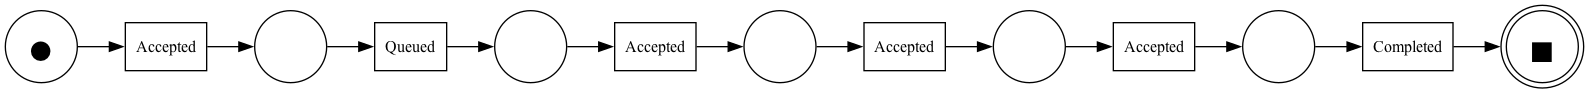

In [16]:
# Build the trace cost functions
# 1. Trace cost function: 1 for every activity in the trace
trace_cost_function = [align_utils.STD_MODEL_LOG_MOVE_COST] * len(trace_to_align)
print("Trace cost function:", trace_cost_function)
# 2. Build the Trace Net
# This creates a simple Petri net that just represents the trace
(
    trace_net,
    trace_im,
    trace_fm,
    trace_net_costs,
) = construct_trace_net_cost_aware(
    trace_to_align, trace_cost_function, activity_key=activity_key
)

# Visualize the trace net
print("Vizualizing the chosen Trace Net, reconstructed as a 'mini' Petri Net:")
trace_to_align_viz = pn_visualizer.apply(trace_net, trace_im, trace_fm)
pn_visualizer.view(trace_to_align_viz)

Vizualizing the discovered process model Petri Net:


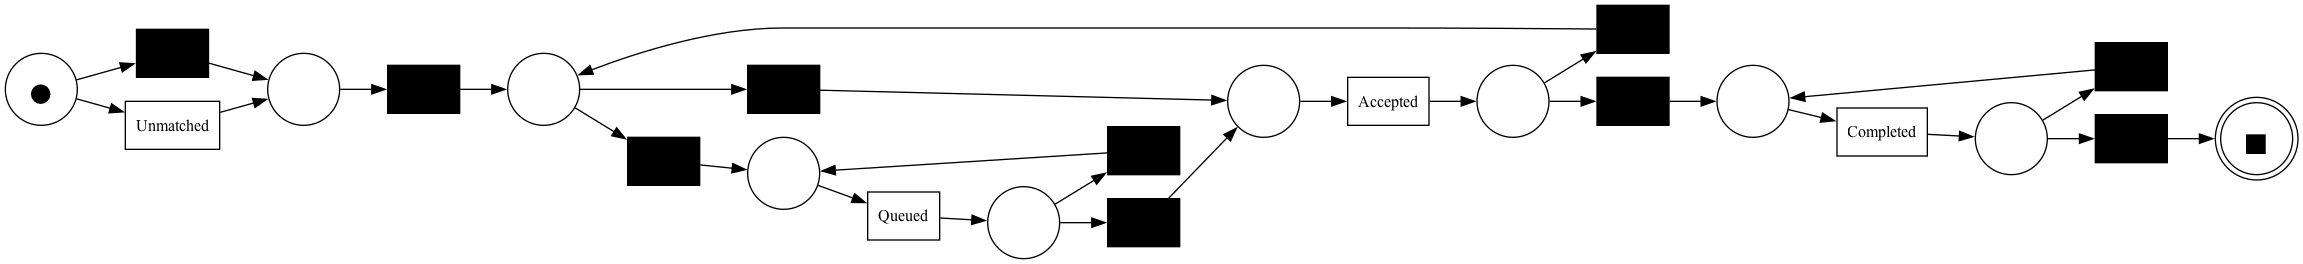

In [17]:
# Discover a process model from the eventlog using the Inductive Miner
model_net, model_im, model_fm = inductive_miner(log_bpi_2012, disable_fallthroughs=False, noise_threshold=0.35)

model_cost_function = {}
for t in model_net.transitions:
    if t.label is not None:
        # This is a "model move"
        model_cost_function[t] = align_utils.STD_MODEL_LOG_MOVE_COST # (which is 10000)
    else:
        # This is a "tau" (silent) move
        model_cost_function[t] = align_utils.STD_TAU_COST # (which is 1)

#print("Model cost function:", model_cost_function)
print("Vizualizing the discovered process model Petri Net:")
model_viz = pn_visualizer.apply(model_net, model_im, model_fm, log=log_bpi_2012)
pn_visualizer.view(model_viz)

In [18]:
sync_cost_function = {}
for t in model_net.transitions:
    if t.label is not None:
        sync_cost_function[t] = align_utils.STD_SYNC_COST # (which is 0)


revised_sync = {}
for t_trace in trace_net.transitions:
    for t_model in model_net.transitions:
        if t_trace.label == t_model.label:
            revised_sync[(t_trace, t_model)] = sync_cost_function.get(t_model, 0)

# This is the "map" A* will search!
sync_prod, sync_initial_marking, sync_final_marking, cost_function = (
    construct_cost_aware(
        trace_net,
        trace_im,
        trace_fm,
        model_net,
        model_im,
        model_fm,
        align_utils.SKIP,
        trace_net_costs,
        model_cost_function,
        revised_sync,
    )
)

print("--- Synchronous Product Net (SPN) ---")
print(f"Original Net Places: {len(model_net.places)}, Transitions: {len(model_net.transitions)}")
print(f"Trace Net Places: {len(trace_net.places)}, Transitions: {len(trace_net.transitions)}")
print(f"SPN Places: {len(sync_prod.places)}, Transitions: {len(sync_prod.transitions)}")




--- Synchronous Product Net (SPN) ---
Original Net Places: 10, Transitions: 14
Trace Net Places: 7, Transitions: 6
SPN Places: 17, Transitions: 26


Viszalizing the constructed Synchronous Product Net (SPN):


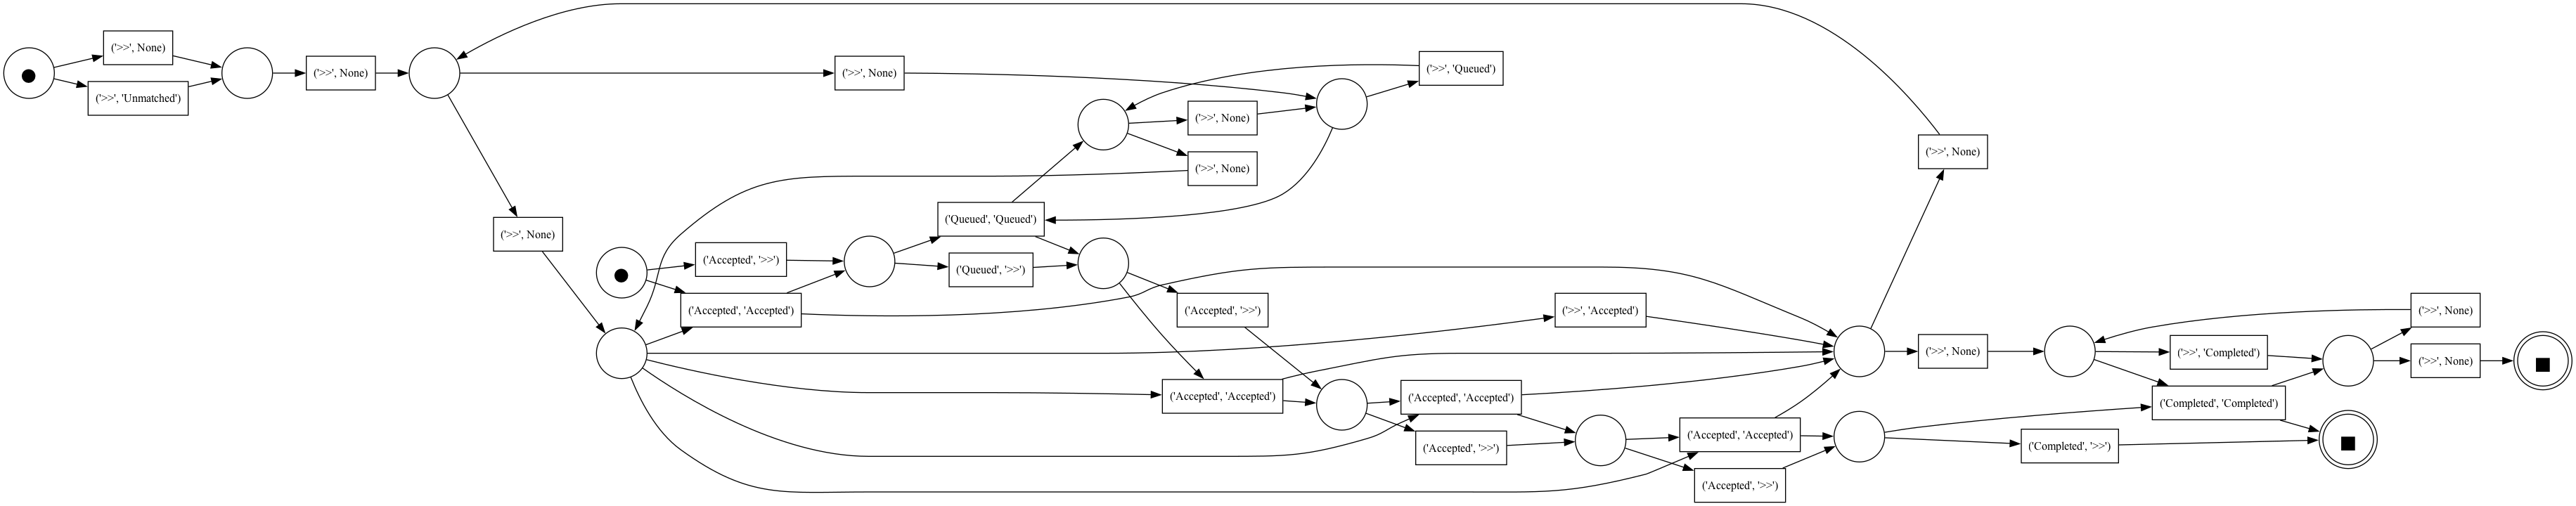

In [19]:
print("Viszalizing the constructed Synchronous Product Net (SPN):")
spn_viz = pn_visualizer.apply(sync_prod, sync_initial_marking, sync_final_marking)
pn_visualizer.view(spn_viz)

In [51]:
candidates = {
    "1. Dijkstra (h=0)": AlignmentsVariants.VERSION_DIJKSTRA_NO_HEURISTICS,
    "2. LP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR,
    "3. ILP-Heuristic": AlignmentsVariants.VERSION_STATE_EQUATION_A_STAR_ILP,
    "4. Incremental A*": AlignmentsVariants.VERSION_INCREMENTAL_A_STAR,
}


import cProfile
import pstats
import io
import pandas as pd

# -------------------------------
# PROFILING UTILITIES
# -------------------------------

def profile_alignment(trace, pm_net, pm_im, pm_fm, variant):
    """Profile only the alignment call, return result and cumulative time (s)."""
    pr = cProfile.Profile()
    pr.enable()
    start_time = time.perf_counter()

    res = alignments_algorithm.apply_trace(
        trace, pm_net, pm_im, pm_fm, parameters=None, variant=variant
    )

    end_time = time.perf_counter()
    pr.disable()

    # Collect stats summary for top 10 functions
    s = io.StringIO()
    ps = pstats.Stats(pr, stream=s).sort_stats("cumtime")
    ps.print_stats(20)
    profile_summary = s.getvalue()

    # Extract specific cumulative times
    search_time = 0.0
    lp_time = 0.0
    for func, (cc, nc, tt, ct, callers) in ps.stats.items():
        fname = func[2]
        if "__search" in fname:
            search_time += ct
        elif "cvxopt.glpk.lp" in fname or "cvxopt.glpk.ilp" in fname:
            lp_time += ct

    total_runtime = end_time - start_time
    search_time_perc = (search_time / total_runtime) * 100 if total_runtime > 0 else 0
    lp_time_perc = (lp_time / search_time) * 100 if search_time > 0 else 0
    return res, total_runtime, search_time, search_time_perc, lp_time, lp_time_perc, profile_summary




def run_alignments_on_trace(candidates_, trace_to_align_, pm_net, pm_im, pm_fm):
    metrics = []
    for name, variant in candidates_.items():
        print(f"\n️ Testing Candidate: {name}")

        res, total_runtime, search_time, search_time_perc, lp_time, lp_time_perc, profile_summary = profile_alignment(
            trace_to_align_, pm_net, pm_im, pm_fm, variant
        )

        if not res:
            print("Returned None")
            continue

        visited = res.get("visited_states", np.nan)
        lp_solved = res.get("lp_solved", np.nan)
        cost = res.get("cost", np.nan)
        alignment_len = len(res.get("alignment", []))

        print(f"SUCCESS: cost={cost}, lp_solved={lp_solved}")
        print(f"Visited states={visited}")
        print(
            f"Total={total_runtime:.4f}s | Search={search_time:.4f}s | LP/ILP={lp_time:.4f}s"
        )
        metrics.append({
            "Variant": name,
            "Cost": cost,
            "Visited States": visited,
            "LP Solved": lp_solved,
            "Alignment Length": alignment_len,
            "Total Runtime (ms)": total_runtime * 1000,
            "__search Runtime (ms)": f"{(search_time * 1000):.2f} ({search_time_perc :.1f}%)",
            "LP/ILP Runtime (ms)": f"{(lp_time * 1000):.2f} ({lp_time_perc :.1f}%)",
            "Profile Summary": profile_summary
        })

    df = pd.DataFrame(metrics)
    print("\n=== Summary ===")
    print(df[[
        "Variant",
        "Total Runtime (ms)",
        "__search Runtime (ms)",
        "LP/ILP Runtime (ms)",
        "Visited States",
        "LP Solved",
        "Cost"
    ]])

    df.to_csv("alignment_trace_metrics.csv", index=False)
    print("\nSaved metrics → alignment_trace_metrics.csv")
    df

    return df


def run_alignments_on_eventlog(candidates_, eventlog, pm_net, pm_im, pm_fm):
    metrics = []

    for name, variant in candidates_.items():
        print('\nTesting Candidate:', name)
        start_time = time.perf_counter()
        res = alignments_algorithm.apply(eventlog, pm_net, pm_im, pm_fm, parameters=None, variant=variant)
        end_time = time.perf_counter()

        if not res:
            print("Returned None")
            continue

        total_runetime = (end_time - start_time)
        visited = [
            r['visited_states']
            for r in res
            if r and r.get('visited_states') is not None
        ]
        avg_visited = np.mean(visited) if visited else float('nan')

        print(f"Runtime: {total_runetime:.3f}s | #Alignments={len(res)} | Avg visited={avg_visited:.1f}")


        metrics.append({
            "Variant": name,
            "Total Runtime (ms)": total_runetime * 1000,
            "Number of Alignments": len(res),
            "Average Time per Alignment (ms)": (total_runetime * 1000) / len(res),
            "Average Visited States": avg_visited
        })

    df = pd.DataFrame(metrics)
    print("\n=== Event Log Summary ===")
    print(df)
    df.to_csv("alignment_log_metrics.csv", index=False)
    print("\nSaved metrics → alignment_log_metrics.csv")

    return df





In [52]:
# select a trace
trace_to_align_bpi2012 = log_bpi_2012[823]
# discover process model
model_net, model_im, model_fm = inductive_miner(log_bpi_2012, disable_fallthroughs=False, noise_threshold=0.23)
print('\nRunning alignments on a single trace:')
run_alignments_on_trace(candidates, trace_to_align_bpi2012, model_net, model_im, model_fm)


Running alignments on a single trace:

️ Testing Candidate: 1. Dijkstra (h=0)
SUCCESS: cost=17, lp_solved=0
Visited states=40
Total=0.0088s | Search=0.0039s | LP/ILP=0.0000s

️ Testing Candidate: 2. LP-Heuristic
SUCCESS: cost=17, lp_solved=3
Visited states=34
Total=0.0536s | Search=0.0452s | LP/ILP=0.0172s

️ Testing Candidate: 3. ILP-Heuristic
SUCCESS: cost=17, lp_solved=3
Visited states=34
Total=0.0080s | Search=0.0057s | LP/ILP=0.0004s

️ Testing Candidate: 4. Incremental A*
SUCCESS: cost=17, lp_solved=26
Visited states=39
Total=0.1234s | Search=0.1176s | LP/ILP=0.0647s

=== Summary ===
             Variant  Total Runtime (ms) __search Runtime (ms)  \
0  1. Dijkstra (h=0)            8.758708          3.92 (44.7%)   
1    2. LP-Heuristic           53.551250         45.16 (84.3%)   
2   3. ILP-Heuristic            8.028458          5.72 (71.3%)   
3  4. Incremental A*          123.415792        117.57 (95.3%)   

  LP/ILP Runtime (ms)  Visited States  LP Solved  Cost  
0         0.00

,Variant,Cost,Visited States,LP Solved,Alignment Length,Total Runtime (ms),__search Runtime (ms),LP/ILP Runtime (ms),Profile Summary
0,1. Dijkstra (h=0),17,40,0,26,8.758708,3.92 (44.7%),0.00 (0.0%),16065 function calls (16059 primitive...
1,2. LP-Heuristic,17,34,3,26,53.551250,45.16 (84.3%),17.17 (38.0%),17271 function calls (17262 primitive...
2,3. ILP-Heuristic,17,34,3,26,8.028458,5.72 (71.3%),0.37 (6.5%),17542 function calls (17536 primitive...
3,4. Incremental A*,17,39,26,26,123.415792,117.57 (95.3%),64.74 (55.1%),32008 function calls (32000 primitive...


In [53]:
print("\nRunning alignments on the entire eventlog:")
run_alignments_on_eventlog(candidates, log_bpi_2012, model_net, model_im, model_fm)


Running alignments on the entire eventlog:

Testing Candidate: 1. Dijkstra (h=0)



aligning log, completed variants :: 100%|██████████| 183/183 [00:00<00:00, 473.98it/s]


Runtime: 0.409s | #Alignments=1487 | Avg visited=21.4

Testing Candidate: 2. LP-Heuristic



aligning log, completed variants :: 100%|██████████| 183/183 [00:00<00:00, 302.55it/s]


Runtime: 0.611s | #Alignments=1487 | Avg visited=16.5

Testing Candidate: 3. ILP-Heuristic



aligning log, completed variants :: 100%|██████████| 183/183 [00:00<00:00, 271.18it/s]


Runtime: 0.681s | #Alignments=1487 | Avg visited=16.2

Testing Candidate: 4. Incremental A*



aligning log, completed variants :: 100%|██████████| 183/183 [00:11<00:00, 16.49it/s]

Runtime: 11.101s | #Alignments=1487 | Avg visited=17.4

=== Event Log Summary ===
             Variant  Total Runtime (ms)  Number of Alignments  \
0  1. Dijkstra (h=0)          408.539209                  1487   
1    2. LP-Heuristic          611.345500                  1487   
2   3. ILP-Heuristic          681.040208                  1487   
3  4. Incremental A*        11101.325291                  1487   

   Average Time per Alignment (ms)  Average Visited States  
0                         0.274741               21.414929  
1                         0.411127               16.490921  
2                         0.457996               16.183591  
3                         7.465585               17.408204  

Saved metrics → alignment_log_metrics.csv


,Variant,Total Runtime (ms),Number of Alignments,Average Time per Alignment (ms),Average Visited States
0,1. Dijkstra (h=0),408.539209,1487,0.274741,21.414929
1,2. LP-Heuristic,611.345500,1487,0.411127,16.490921
2,3. ILP-Heuristic,681.040208,1487,0.457996,16.183591
3,4. Incremental A*,11101.325291,1487,7.465585,17.408204


In [11]:
log_path2 = "data/5f3067df-f10b-45da-b98b-86ae4c7a310b/BPI%20Challenge%202017.xes"
log_bpi_2017 = xes_importer.apply(log_path2)

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:29<00:00, 1062.14it/s]


In [12]:
# select a trace
trace_to_align_bpi2017 = log_bpi_2017[5123]
# discover process model
model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017 = inductive_miner(log_bpi_2017, disable_fallthroughs=False, noise_threshold=0.21)

In [13]:
trace_to_align_bpi2017 = log_bpi_2017[761]
run_alignments_on_trace(candidates, trace_to_align_bpi2017, model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017)


Testing Candidate: 1. Dijkstra (h=0)
 SUCCESS:
 cost= 70074  lp_solved= 0
 Alignment length= 128
 Visited states= 18710
 Time (ms): 743.4549331665039

Testing Candidate: 2. LP-Heuristic
 SUCCESS:
 cost= 70074  lp_solved= 21769
 Alignment length= 128
 Visited states= 12886
 Time (ms): 7327.662944793701

Testing Candidate: 3. ILP-Heuristic
 SUCCESS:
 cost= 70074  lp_solved= 21726
 Alignment length= 128
 Visited states= 12886
 Time (ms): 8096.499919891357

Testing Candidate: 4. Incremental A*
 SUCCESS:
 cost= 80073  lp_solved= 18241
 Alignment length= 127
 Visited states= 18074
 Time (ms): 1772672.4691390991


In [72]:
#run_alignments_on_eventlog(candidates, log_bpi_2017, model_net_bpi2017, model_im_bpi2017, model_fm_bpi2017)

aligning log, completed variants ::  23%|██▎       | 3620/15930 [31:12<2:15:10,  1.52it/s] 

KeyboardInterrupt: 